## **Task 1**

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import accuracy_score
from sklearn.metrics import hamming_loss
from sklearn.metrics import jaccard_score
X, Y = fetch_openml("emotions", version=4, return_X_y=True)
Y = (Y == "TRUE").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42,
)

In [2]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [3]:
import sklearn
print(sklearn.__version__)

1.4.2


In [4]:
import pandas as pd

## **Preliminary analysis of labels**

### How many labels are there?

In [5]:
Y

,amazed.suprised,happy.pleased,relaxing.calm,quiet.still,sad.lonely,angry.aggresive
0,0,1,1,0,0,0
1,1,0,0,0,0,1
2,0,1,0,0,0,1
3,0,0,1,0,0,0
4,0,0,0,1,0,0
...,...,...,...,...,...,...
588,0,0,1,1,1,0
589,1,0,0,0,1,1
590,0,0,1,1,1,0
591,0,1,1,0,0,0


In [6]:
Y.shape[1]

6

There are 6 labels.

### What is the empirical frequency of each label?

In [7]:
Y.mean()

amazed.suprised    0.291737
happy.pleased      0.279933
relaxing.calm      0.445194
quiet.still        0.249578
sad.lonely         0.283305
angry.aggresive    0.318718
dtype: float64

### How many active labels does one observation have on average?

In [8]:
Y.sum(axis=1).mean()

1.8684654300168635

### Which pairs of labels are most strongly correlated?

In [9]:
corr_matrix = Y.corr()

In [10]:
corr_matrix

,amazed.suprised,happy.pleased,relaxing.calm,quiet.still,sad.lonely,angry.aggresive
amazed.suprised,1.000000,0.062565,-0.477873,-0.370126,-0.321184,0.293468
happy.pleased,0.062565,1.000000,0.129219,-0.298822,-0.383677,-0.329735
relaxing.calm,-0.477873,0.129219,1.000000,0.298812,0.152166,-0.561723
quiet.still,-0.370126,-0.298822,0.298812,1.000000,0.545410,-0.377725
sad.lonely,-0.321184,-0.383677,0.152166,0.545410,1.000000,-0.269406
angry.aggresive,0.293468,-0.329735,-0.561723,-0.377725,-0.269406,1.000000


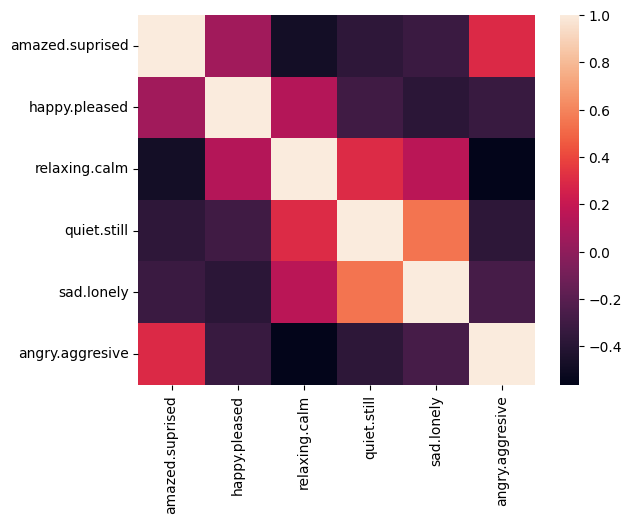

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix)
plt.show()

The pairs that are most strongly correlated:
1. relaxing.calm & angry.aggressive: -0.561723
2. sad.lonely & quiet.still: 0.545410
3. amazed.suprised & relaxing.calm: -0.477873

### Are the labels approximately independent? Why does this matter for multi-label classification?

Looking on the correlation table, the labels are not completely independent but they are also not strongly dependent.<br>
This is important because some methods, such as BR, assume label independence.

## **Task 2**

In [12]:
def evaluate(name, Y_true, Y_pred):
    subset_acc = accuracy_score(Y_true, Y_pred)
    hamming = 1 - hamming_loss(Y_true, Y_pred)
    jacc = jaccard_score(Y_true, Y_pred, average="samples")
    print(
        f"{name:5}␣− >␣"
        f"Subset␣accuracy :␣{subset_acc:.3f},␣"
        f"Hamming␣score :␣{hamming:.3f},␣"
        f"Jaccard␣score :␣{jacc:.3f}"
    )

Models with evaluation

### **1. Binary Relevance (BR)**

In [13]:
br = OneVsRestClassifier(LogisticRegression(solver="liblinear"))

br.fit(X_train, y_train)



OneVsRestClassifier(estimator=LogisticRegression(solver='liblinear'))

In [14]:
y_pred_br = br.predict(X_test)

### **Classifier Chains (CC)**

In [15]:
cc = ClassifierChain(order="random", base_estimator=LogisticRegression(solver="liblinear"), random_state=0)

cc.fit(X_train, y_train)

ClassifierChain(base_estimator=LogisticRegression(solver='liblinear'),
                order='random', random_state=0)

In [16]:
y_pred_cc = cc.predict(X_test)

Test at least 10 different random label orders.

In [17]:
cc_results = []

for seed in range(10):
    cc = ClassifierChain(order="random", base_estimator=LogisticRegression(solver="liblinear"), random_state=seed)
    cc.fit(X_train, y_train)
    
    y_pred_cc = cc.predict(X_test)

    cc_results.append(evaluate(
        name=f"CC_seed_{seed}",
        Y_true=y_test,
        Y_pred=y_pred_cc,
    ))

CC_seed_0␣− >␣Subset␣accuracy :␣0.320,␣Hamming␣score :␣0.794,␣Jaccard␣score :␣0.558
CC_seed_1␣− >␣Subset␣accuracy :␣0.303,␣Hamming␣score :␣0.789,␣Jaccard␣score :␣0.550
CC_seed_2␣− >␣Subset␣accuracy :␣0.315,␣Hamming␣score :␣0.787,␣Jaccard␣score :␣0.551
CC_seed_3␣− >␣Subset␣accuracy :␣0.348,␣Hamming␣score :␣0.793,␣Jaccard␣score :␣0.565
CC_seed_4␣− >␣Subset␣accuracy :␣0.354,␣Hamming␣score :␣0.811,␣Jaccard␣score :␣0.590
CC_seed_5␣− >␣Subset␣accuracy :␣0.326,␣Hamming␣score :␣0.800,␣Jaccard␣score :␣0.574
CC_seed_6␣− >␣Subset␣accuracy :␣0.343,␣Hamming␣score :␣0.808,␣Jaccard␣score :␣0.586
CC_seed_7␣− >␣Subset␣accuracy :␣0.337,␣Hamming␣score :␣0.796,␣Jaccard␣score :␣0.565
CC_seed_8␣− >␣Subset␣accuracy :␣0.292,␣Hamming␣score :␣0.782,␣Jaccard␣score :␣0.532
CC_seed_9␣− >␣Subset␣accuracy :␣0.326,␣Hamming␣score :␣0.795,␣Jaccard␣score :␣0.559


### **Ensemble of Classifier Chains (ECC)**

Use at least M = 20 chains and combine predictions by majority voting

In [18]:
M = 20
predictions = []

for seed in range(M):
    cc = ClassifierChain(order="random", base_estimator=LogisticRegression(solver="liblinear"), random_state=seed)
    cc.fit(X_train, y_train)

    y_pred = cc.predict(X_test)

    predictions.append(y_pred)

predictions = np.array(predictions)
y_pred_ecc = (predictions.mean(axis=0) >= 0.5).astype(int)

#### **Evaluation**

In [19]:
# modified in order to save results to compare

def evaluate_return(name, Y_true, Y_pred):
    subset_acc = accuracy_score(Y_true, Y_pred)
    hamming = 1 - hamming_loss(Y_true, Y_pred)
    jacc = jaccard_score(Y_true, Y_pred, average="samples")

    return {
        "method": name,
        "subset_accuracy": subset_acc,
        "hamming_score": hamming,
        "jaccard_score": jacc,
    }

In [20]:
results = []

# br
results.append(evaluate_return(name="BR", Y_true=y_test, Y_pred=y_pred_br))

# cc
for seed in range(10):
    cc = ClassifierChain(order="random", base_estimator=LogisticRegression(solver="liblinear"), random_state=seed)
    cc.fit(X_train, y_train)
    
    y_pred_cc = cc.predict(X_test)

    results.append(evaluate_return(
        name=f"CC_seed_{seed}",
        Y_true=y_test,
        Y_pred=y_pred_cc,
    ))

# ecc
results.append(evaluate_return(name="ECC", Y_true=y_test, Y_pred=y_pred_ecc))

In [21]:
results_df = pd.DataFrame(results)
results_df

,method,subset_accuracy,hamming_score,jaccard_score
0,BR,0.269663,0.794944,0.492509
1,CC_seed_0,0.320225,0.794007,0.557772
2,CC_seed_1,0.303371,0.789326,0.549625
3,CC_seed_2,0.314607,0.787453,0.551030
4,CC_seed_3,0.348315,0.793071,0.564607
5,CC_seed_4,0.353933,0.810861,0.589888
6,CC_seed_5,0.325843,0.799625,0.574438
7,CC_seed_6,0.342697,0.808052,0.586142
8,CC_seed_7,0.337079,0.795880,0.564607
9,CC_seed_8,0.292135,0.781835,0.532022


The best score is achieed for CC_seed_4.<br>
BR has the poorest results, probably because as seen in task 1, the labels are not completely and perfectly independent.<br>
And ECC performs quite worse than CC_seed_4 but similar (probably becuase of the voting - mean of a few chain results) and is better for some other seeds in CC.

## **Task 3**
### **Circular Chain Classifier**

### **Training**

In [22]:
def fit_ccc(X_train, y_train):
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    n_labels = y_train.shape[1]
    models = []

    for k in range(n_labels):
        Y_minus_k = np.delete(y_train, k, axis=1)

        X_and_labels = np.hstack([X_train, Y_minus_k])

        y_target_k = y_train[:, k]

        model = LogisticRegression(solver="liblinear")
        model.fit(X_and_labels, y_target_k)

        models.append(model)
    return models

### **Prediction**

In [23]:
def predict_ccc(
    models,
    X_test,
    init="zeros",
    br_model=None,
    max_iter=20,
    random_state=None,
    permutation=None
):
    X_test = np.array(X_test)

    n_samples = X_test.shape[0]
    n_labels = len(models)

    # y_hat initizalisation
    if init == "zeros":
        Y_hat = np.zeros((n_samples, n_labels), dtype=int)
    elif init == "random":
        if random_state is not None:
            np.random.seed(random_state)
        Y_hat = np.random.randint(0, 2, size=(n_samples, n_labels))
    elif init == "br":
        Y_hat = br_model.predict(X_test).astype(int)
    else:
        raise ValueError("Available methods of y_hat initialisation (init parameter) are: 'zeros', 'random' or 'br")
    
    # permutation
    if permutation is None:
        permutation_order = np.random.permutation(n_labels)
    else:
        permutation_order = permutation
    
    converged = False

    iter = 0
    while not converged:
        iter += 1
        Y_hat_old = Y_hat.copy()

        for k in permutation_order:
            Y_hat_minus_k = np.delete(Y_hat, k, axis=1)

            X_and_labels_pred = np.hstack([X_test, Y_hat_minus_k])

            proba = models[k].predict_proba(X_and_labels_pred)[:, 1]

            # label actualisation
            Y_hat[:, k] = (proba > 0.5).astype(int)

        if np.array_equal(Y_hat, Y_hat_old):
            converged = True

        if converged == False and iter >= max_iter:
            break
    
    if converged:
        print("The loop procedure has ended due to convergence")
    else:
        print("The loop has ended because max iteration was reached")

    return Y_hat, iter

In [24]:
ccc_models = fit_ccc(X_train=X_train, y_train=y_train)

### **Experiments**

#### **Compare CCC with random initialization, zero initialization, and BR initialization.**

In [25]:
# br for initialisation
br = OneVsRestClassifier(LogisticRegression(solver="liblinear"))
br.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression(solver='liblinear'))

In [26]:
ccc_results = []

for init in ["zeros", "random", "br"]:
    print("=" * 22)
    print(f"Running CCC for initialisation method: {init}")
    y_pred_ccc, iter = predict_ccc(
        models=ccc_models,
        X_test=X_test,
        init=init,
        br_model=br,
    )

    result = evaluate_return(
        name=f"CCC_{init}",
        Y_true=y_test,
        Y_pred=y_pred_ccc,
    )

    result["iterations"] = iter

    ccc_results.append(result)

ccc_results_df = pd.DataFrame(ccc_results)
ccc_results_df

Running CCC for initialisation method: zeros
The loop procedure has ended due to convergence
Running CCC for initialisation method: random
The loop procedure has ended due to convergence
Running CCC for initialisation method: br
The loop procedure has ended due to convergence


,method,subset_accuracy,hamming_score,jaccard_score,iterations
0,CCC_zeros,0.292135,0.750000,0.478652,4
1,CCC_random,0.247191,0.733146,0.455056,4
2,CCC_br,0.342697,0.805243,0.590356,2


#### **Check whether the result depends strongly on the random initialization.**

In [27]:
random_init_results = []

fixed_perm = np.arange(y_train.shape[1])

for seed in range(10):
    y_pred_ccc, iter = predict_ccc(
        models=ccc_models,
        X_test=X_test,
        init="random",
        br_model=br,
        random_state=seed,
        permutation=fixed_perm,
    )

    result = evaluate_return(
        name=f"CCC_random_init_{seed}",
        Y_true=y_test,
        Y_pred=y_pred_ccc,
    )

    result["iterations"] = iter

    random_init_results.append(result)

random_init_df = pd.DataFrame(random_init_results)
random_init_df

The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence


,method,subset_accuracy,hamming_score,jaccard_score,iterations
0,CCC_random_init_0,0.314607,0.761236,0.518446,4
1,CCC_random_init_1,0.280899,0.750000,0.478933,4
2,CCC_random_init_2,0.280899,0.750936,0.481742,5
3,CCC_random_init_3,0.264045,0.747191,0.470974,5
4,CCC_random_init_4,0.292135,0.752809,0.486891,4
5,CCC_random_init_5,0.275281,0.741573,0.471442,4
6,CCC_random_init_6,0.264045,0.738764,0.461142,4
7,CCC_random_init_7,0.297753,0.764045,0.510768,4
8,CCC_random_init_8,0.264045,0.737828,0.466760,4
9,CCC_random_init_9,0.275281,0.751873,0.484082,5


In [28]:
random_init_df[["subset_accuracy", "hamming_score", "jaccard_score", "iterations"]].agg(["mean", "std"])

,subset_accuracy,hamming_score,jaccard_score,iterations
mean,0.280899,0.749625,0.483118,4.300000
std,0.016539,0.008741,0.018504,0.483046


#### **Observations**
The results vary slightly depend on the random initialization. <br>
The standard deviation of Jaccard score is about 0.019, so the dependence is visible but not very strong.<br>
All runs converged in 4 or 5 iterations with an average of 4.3 iterations.

### **Check whether the result depends strongly on the permutation σ.**

In [29]:
permutations_results = []

n_labels = y_train.shape[1]

for seed in range(10):
    np.random.seed(seed)
    permutation = np.random.permutation(n_labels)

    y_pred_ccc, iter = predict_ccc(
        models=ccc_models,
        X_test=X_test,
        init="br",
        br_model=br,
        permutation=permutation,
    )

    result = evaluate_return(
        name=f"CCC_permutation_{seed}",
        Y_true=y_test,
        Y_pred=y_pred_ccc,
    )

    result["iterations"] = iter
    result["permutation"] = str(permutation.tolist())

    permutations_results.append(result)

permutations_results_df = pd.DataFrame(permutations_results)
permutations_results_df

The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence
The loop procedure has ended due to convergence


,method,subset_accuracy,hamming_score,jaccard_score,iterations,permutation
0,CCC_permutation_0,0.325843,0.788390,0.564139,3,"[5, 2, 1, 3, 0, 4]"
1,CCC_permutation_1,0.342697,0.798689,0.583333,3,"[2, 1, 4, 0, 3, 5]"
2,CCC_permutation_2,0.342697,0.800562,0.586142,3,"[4, 1, 3, 2, 5, 0]"
3,CCC_permutation_3,0.331461,0.791199,0.569288,3,"[3, 5, 4, 1, 0, 2]"
4,CCC_permutation_4,0.325843,0.794944,0.571161,3,"[4, 5, 3, 0, 1, 2]"
5,CCC_permutation_5,0.320225,0.786517,0.561330,3,"[5, 2, 4, 1, 0, 3]"
6,CCC_permutation_6,0.325843,0.794944,0.571161,3,"[4, 5, 0, 3, 1, 2]"
7,CCC_permutation_7,0.331461,0.791199,0.568352,3,"[3, 5, 0, 2, 1, 4]"
8,CCC_permutation_8,0.331461,0.795880,0.579120,3,"[0, 2, 5, 1, 4, 3]"
9,CCC_permutation_9,0.325843,0.788390,0.564139,3,"[5, 1, 2, 3, 0, 4]"


In [30]:
permutations_results_df[["subset_accuracy", "hamming_score", "jaccard_score", "iterations"]].agg(["mean", "std"])

,subset_accuracy,hamming_score,jaccard_score,iterations
mean,0.330337,0.793071,0.571816,3.0
std,0.007396,0.004671,0.008422,0.0


#### **Observations**
The results do not depend strongly on the permutation order as well.<br> 
The standard deviation of Jaccard score is only about 0.008, which is even smaller than for random initialization.<br>
All runs converged in 3 iterations.

### **Compare CCC with BR, CC, and ECC using the same evaluation metrics.**

In [31]:
best_ccc = ccc_results_df.sort_values("jaccard_score", ascending=False).iloc[0]

comparison_df = pd.concat([
        results_df,
        pd.DataFrame([best_ccc])],
    ignore_index=True
)

comparison_df.sort_values("jaccard_score", ascending=False)

,method,subset_accuracy,hamming_score,jaccard_score,iterations
12,CCC_br,0.342697,0.805243,0.590356,2.0
5,CC_seed_4,0.353933,0.810861,0.589888,NaN
7,CC_seed_6,0.342697,0.808052,0.586142,NaN
6,CC_seed_5,0.325843,0.799625,0.574438,NaN
11,ECC,0.331461,0.801498,0.569288,NaN
4,CC_seed_3,0.348315,0.793071,0.564607,NaN
8,CC_seed_7,0.337079,0.795880,0.564607,NaN
10,CC_seed_9,0.325843,0.794944,0.558708,NaN
1,CC_seed_0,0.320225,0.794007,0.557772,NaN
3,CC_seed_2,0.314607,0.787453,0.551030,NaN


#### **Observations**
The best result is obtained by a single Classifier Chain with seed 4.<br>
ECC is slightly worse than the best single CC, but it is probably more stable since it averages predictions from many chains.<br>
CCC with BR initialization gives results close to ECC and better than BR.<br>
BR has the weakest Jaccard score, probably because it ignores dependencies between labels and for this data here, there are some dependeces between labels.

### **Report the average number of iterations needed until stabilization.**

In [32]:
print(f'Average number of iterations in random initialization experiment until stabilization: {random_init_df["iterations"].mean()}')
print(f'Average number of iterations in different permutations experiment until stabilization: {permutations_results_df["iterations"].mean()}')

Average number of iterations in random initialization experiment until stabilization: 4.3
Average number of iterations in different permutations experiment until stabilization: 3.0


#### **Observations**
CCC stabilizes quickly.<br>
For random initialization it needed on average 4.3 iterations, while for different permutations with BR initialization it needed 3 iterations on average.

## **Questions**

#### **1. What label-dependence assumption is made by Binary Relevance?**

Binary Relevance assumes that labels are conditionally independent given the input features. Each label is predicted separately and dependencies between labels are ignored.

#### **2. Why can the order of labels influence Classifier Chains?**

In Classifier Chains, predictions of earlier labels are used as additional features for later labels. So because of this, changing the label order changes the information available to each classifier and may lead to different predictions.

#### **3. Why should ECC be more stable than a single Classifier Chain?**

ECC combines predictions from many classifier chains with different random label orders. <br>
It combines it by averaging or voting across multiple chains which reduces the effect of any specific ordering and results in a more stable result.

#### **4. Why is subset accuracy usually much smaller than Hamming score?**

Subset accuracy is very strict because it requires the entire label vector to be predicted well. One wrong label makes the whole prediction incorrect.<br>
Hamming score, on the other hand,  evaluates labels individually so it is much less strict and usually higher.

#### **5. Why is Jaccard score often more informative than Hamming score when active labels are rare?**

When active labels are rare (there are a lot of zeros), a model can achieve a high Hamming score by correctly predicting many inactive labels (zeros).<br>
While, Jaccard score evaluates how well the predicted set of active labels matches the true set of active labels. This makes it more infromative than Hamming score.

#### **6. Why can CCC be viewed as searching for a self-consistent label vector?**

CCC repeatedly updates each label prediction using the current values of all other labels. The procedure continues until predictions stop changing, producing a label vector that is consistent with all conditional models simultaneously.

#### **7. Does CCC define one coherent joint model P(Y1,...,YK |X= x), or only a collection of conditional models? Why is this distinction important?**

CCC defines a collection of conditional models rather than a single coherent joint probability model. Each classifier estimates one conditional distribution and it does not necessariy correspond to an actual joint distribution.<br>
This distinction is important because a coherent joint model defines probabilities for complete label combinations. CCC only combines separate conditional models, so it can produce good predictions but doesn't have to correspond to the true joint distribution.